In [101]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [102]:
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [103]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [104]:
train_data.info()
train_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [105]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

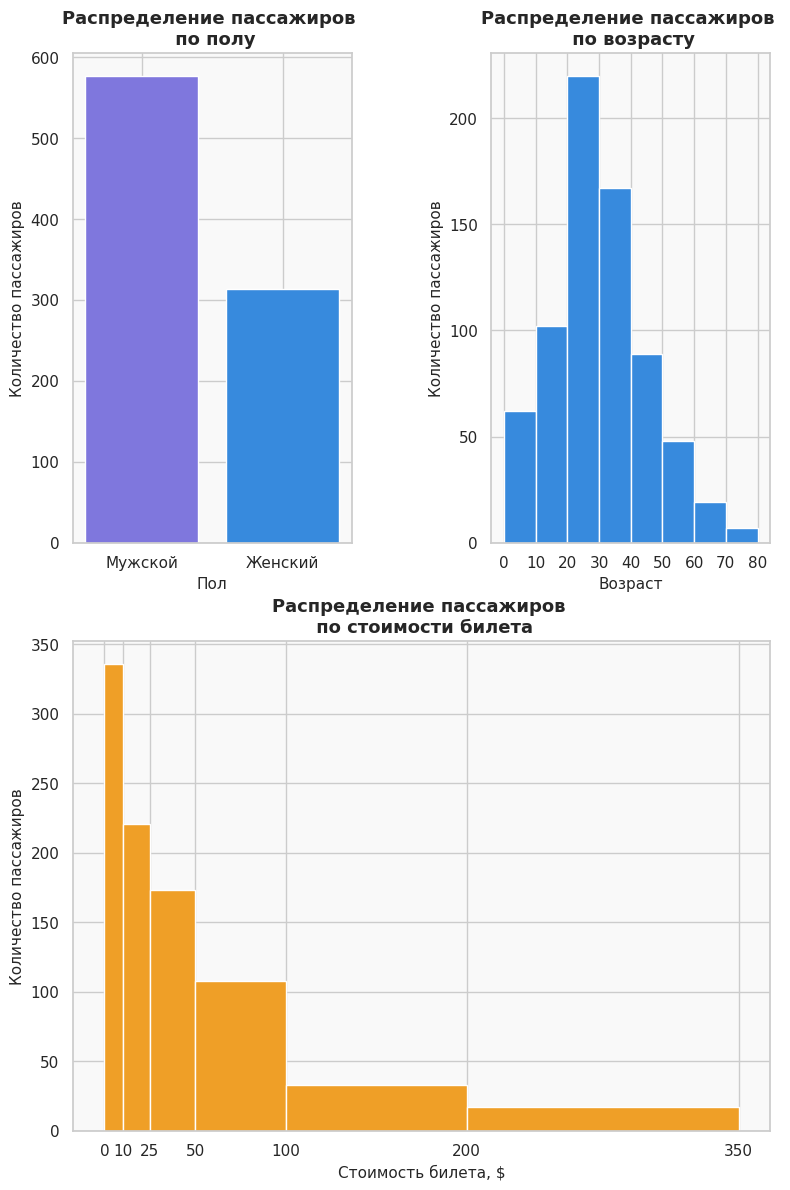

In [106]:
SURVIVED_COLOR = "#1D9E75"
DIED_COLOR = "#E24B4A"
BLUE = "#378ADD"
AMBER = "#EF9F27"
PURPLE = "#7F77DD"

fig = plt.figure(figsize=(9, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.2, wspace=0.5)

sex_hist = fig.add_subplot(gs[0,0])
sex_counts = train_data["Sex"].value_counts()
sex_labels = ["Мужской", "Женский"]
sex_hist.bar(
    sex_labels,
    sex_counts.values,  
    color=[PURPLE, BLUE]
)

sex_hist.set_title("Распределение пассажиров \n по полу", fontsize=13, fontweight="bold")
sex_hist.set_xlabel("Пол", fontsize=11)
sex_hist.set_ylabel("Количество пассажиров", fontsize=11)

age_hist = fig.add_subplot(gs[0,1])
age_counts = train_data["Age"].dropna()
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_hist.hist(
    age_counts,
    bins = age_bins,
    color = [BLUE]
)

age_hist.set_title("Распределение пассажиров \n по возрасту", fontsize=13, fontweight="bold")
age_hist.set_xlabel("Возраст", fontsize=11)
age_hist.set_ylabel("Количество пассажиров", fontsize=11)
age_hist.set_xticks(age_bins)

fare_hist = fig.add_subplot(gs[1,:2])
fare_counts = train_data["Fare"].dropna()
fare_bins = [0, 10, 25, 50, 100, 200, 350]
fare_hist.hist(
    fare_counts,
    bins = fare_bins,
    color=[AMBER]
)

fare_hist.set_title("Распределение пассажиров \n по стоимости билета", fontsize=13, fontweight="bold")
fare_hist.set_xlabel("Стоимость билета, $", fontsize=11)
fare_hist.set_ylabel("Количество пассажиров", fontsize=11)
fare_hist.set_xticks(fare_bins)

fig.savefig("plot1.svg")

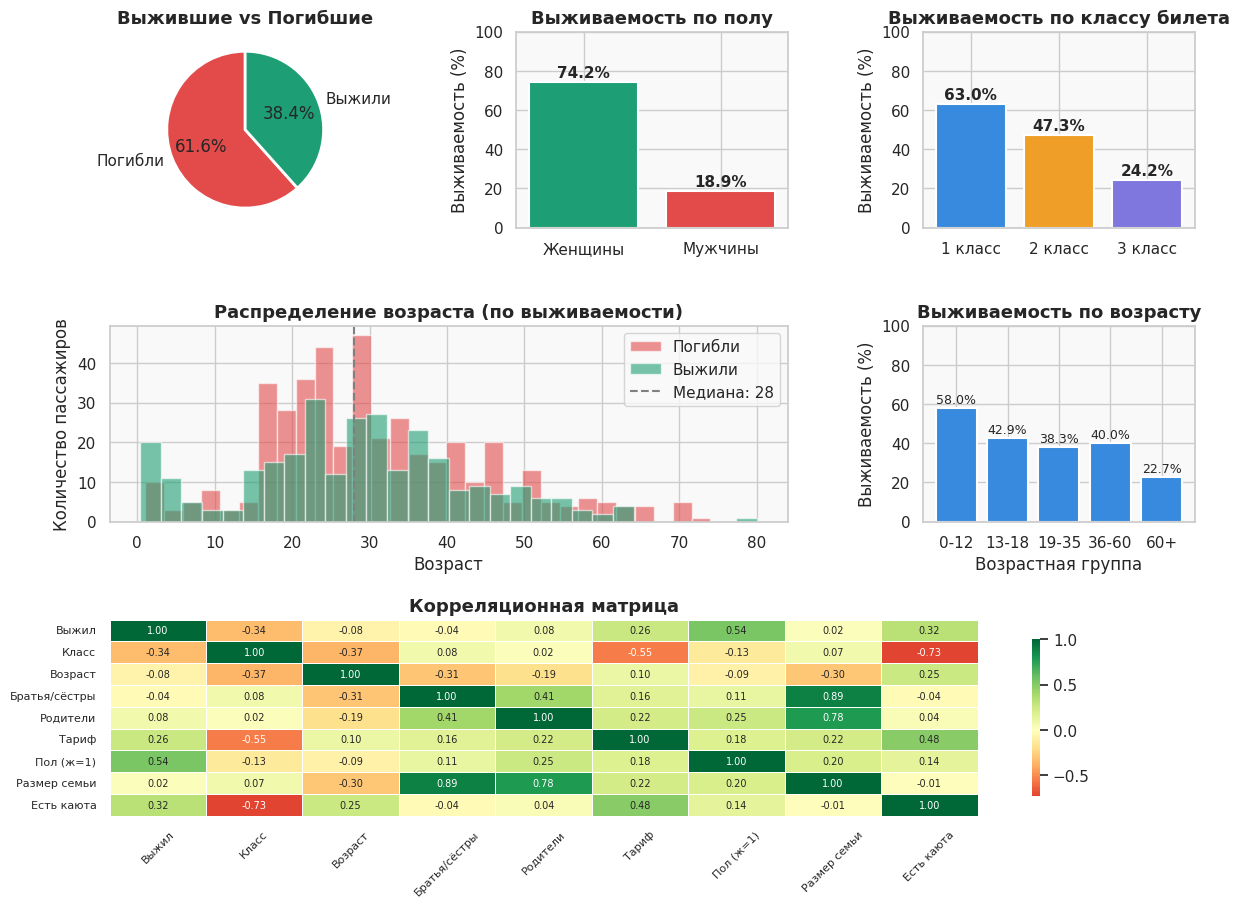

In [154]:
fig1 = plt.figure(figsize=(14, 14))
gs = gridspec.GridSpec(4, 3, figure=fig1, hspace=0.5, wspace=0.5)
ax0 = fig1.add_subplot(gs[0, 0])
counts = train_data["Survived"].value_counts()
ax0.pie(
    counts,
    labels=["Погибли", "Выжили"],
    colors=[DIED_COLOR, SURVIVED_COLOR],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax0.set_title("Выжившие vs Погибшие", fontsize=13, fontweight="bold")

ax1 = fig1.add_subplot(gs[0, 1])
sex_surv = train_data.groupby("Sex")["Survived"].mean() * 100
bars = ax1.bar(
    ["Женщины", "Мужчины"],
    [sex_surv["female"], sex_surv["male"]],
    color=[SURVIVED_COLOR, DIED_COLOR],
    edgecolor="white",
    linewidth=1.5,
)
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
ax1.set_ylim(0, 100)
ax1.set_ylabel("Выживаемость (%)")
ax1.set_title("Выживаемость по полу", fontsize=13, fontweight="bold")

ax2 = fig1.add_subplot(gs[0, 2])
class_surv = train_data.groupby("Pclass")["Survived"].mean() * 100
bars2 = ax2.bar(
    ["1 класс", "2 класс", "3 класс"],
    [class_surv[1], class_surv[2], class_surv[3]],
    color=[BLUE, AMBER, PURPLE],
    edgecolor="white",
    linewidth=1.5,
)
for bar in bars2:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
ax2.set_ylim(0, 100)
ax2.set_ylabel("Выживаемость (%)")
ax2.set_title("Выживаемость по классу билета", fontsize=13, fontweight="bold")

ax3 = fig1.add_subplot(gs[1, :2])
survived_ages = train_data[train_data["Survived"] == 1]["Age"].dropna()
died_ages = train_data[train_data["Survived"] == 0]["Age"].dropna()
ax3.hist(died_ages, bins=30, alpha=0.6, color=DIED_COLOR, label="Погибли", edgecolor="white")
ax3.hist(survived_ages, bins=30, alpha=0.6, color=SURVIVED_COLOR, label="Выжили", edgecolor="white")
ax3.axvline(train_data["Age"].median(), color="gray", linestyle="--", linewidth=1.5, label=f"Медиана: {train_data['Age'].median():.0f}")
ax3.set_xlabel("Возраст")
ax3.set_ylabel("Количество пассажиров")
ax3.set_title("Распределение возраста (по выживаемости)", fontsize=13, fontweight="bold")
ax3.legend()

train_data["AgeBin"] = pd.cut(
    train_data["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["0-12", "13-18", "19-35", "36-60", "60+"],
)
ax4 = fig1.add_subplot(gs[1, 2])
age_surv = train_data.groupby("AgeBin", observed=False)["Survived"].mean() * 100
ax4.bar(age_surv.index, age_surv.values, color=BLUE, edgecolor="white", linewidth=1.5)
ax4.set_xlabel("Возрастная группа")
ax4.set_ylabel("Выживаемость (%)")
ax4.set_ylim(0, 100)
ax4.set_title("Выживаемость по возрасту", fontsize=13, fontweight="bold")
for i, v in enumerate(age_surv.values):
    ax4.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1
train_data["IsAlone"] = (train_data["FamilySize"] == 1).astype(int)
train_data["HasCabin"] = train_data["Cabin"].notna().astype(int)
train_data["Sex_bin"] = (train_data["Sex"] == "female").astype(int)
train_data["AgeBin"] = pd.cut(
    train_data["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["0-12", "13-18", "19-35", "36-60", "60+"],
)
train_data["FareBin"] = pd.cut(
    train_data["Fare"],
    bins=[0, 10, 30, 60, 100, 600],
    labels=["0-10", "10-30", "30-60", "60-100", "100+"],
)

ax7 = fig1.add_subplot(gs[2, :3])
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Sex_bin", "FamilySize", "HasCabin"]
corr_matrix = train_data[corr_cols].corr().round(2)
corr_labels = {
    "Survived": "Выжил", "Pclass": "Класс", "Age": "Возраст",
    "SibSp": "Братья/сёстры", "Parch": "Родители", "Fare": "Тариф",
    "Sex_bin": "Пол (ж=1)", "FamilySize": "Размер семьи", "HasCabin": "Есть каюта",
}
corr_matrix.index = [corr_labels[c] for c in corr_matrix.index]
corr_matrix.columns = [corr_labels[c] for c in corr_matrix.columns]
sns.heatmap(
    corr_matrix,
    ax=ax7,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)
ax7.set_title("Корреляционная матрица", fontsize=13, fontweight="bold")
ax7.tick_params(axis="x", rotation=45, labelsize=8)
ax7.tick_params(axis="y", rotation=0, labelsize=8)